# _San Francisco BART Yolcu Analizi ve Talep Tahmini_

<img src='https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQWJ3P-GiTtGixxPjBP9H7Pu_4CRzTaHoNdhg&s'>

_Bu projede 2016–2017 BART yolcu verileri analiz edilerek en yoğun istasyonlar, en az kullanılan rotalar ve koltuk bulma ihtimalinin en yüksek olduğu zaman dilimleri belirlenmiştir. Çalışma, veri temizleme, birleştirme ve gerçek hayat ulaşım kararlarını destekleyen içgörüler üretmeye odaklanmaktadır._

### _İmport_

In [1]:
import pandas as pd
pd.set_option('display.max_columns', 55)
# Pandas DataFrame çıktılarında tüm sütunların görünmesini sağlar.

import warnings
warnings.filterwarnings('ignore')
# Uyarıları gizler, böylece kod çalışırken kullanıcıyı rahatsız etmez.

from sklearn.linear_model import LinearRegression, Ridge, Lasso
# LinearRegression: Doğrusal regresyon modelini kullanır.
# Ridge: L2 regularizasyonu ile doğrusal regresyon.
# Lasso: L1 regularizasyonu ile doğrusal regresyon.

from sklearn.model_selection import train_test_split
# Veriyi eğitim ve test setlerine ayırır.

from sklearn.metrics import r2_score, mean_squared_error
# r2_score: Modelin açıklama gücünü ölçer.
# mean_squared_error: Modelin hata oranını ölçer, kareler ortalaması hatası.

import numpy as np  # NumPy, matematiksel ve matris işlemleri için kullanılır.

import matplotlib.pyplot as plt
# Veriyi görselleştirmek için grafikler çizen kütüphane.

import seaborn as sns
# Veri görselleştirme kütüphanesi, genellikle daha estetik ve kompleks grafikler oluşturur.

### _Read Data_

In [2]:
df_2016 = pd.read_csv('date-hour-soo-dest-2016.csv')
# 'date-hour-soo-dest-2016.csv' dosyasını okur ve DataFrame (df) olarak yükler.

In [3]:
df_2017 = pd.read_csv('date-hour-soo-dest-2017.csv')
# 'date-hour-soo-dest-2017.csv' dosyasını okur ve DataFrame (df) olarak yükler.

### _Data Preparation_

In [4]:
df = pd.concat([df_2016, df_2017])
# 2016 ve 2017 verilerini birleştir

### _Eda_

In [5]:
df.head()
# DataFrame'in ilk 5 satırını gösterir. Veri yapısının hızlıca gözlemlenmesi için kullanılır.

,Origin,Destination,Throughput,DateTime
0,12TH,12TH,1,2016-01-01 00:00:00
1,12TH,16TH,1,2016-01-01 00:00:00
2,12TH,24TH,4,2016-01-01 00:00:00
3,12TH,ASHB,4,2016-01-01 00:00:00
4,12TH,BALB,2,2016-01-01 00:00:00


In [6]:
df.tail()
# DataFrame'in son 5 satırını gösterir. Verinin son kısmına bakmak için kullanılır.

,Origin,Destination,Throughput,DateTime
3313620,WSPR,MONT,1,2017-05-03 23:00:00
3313621,WSPR,NBRK,1,2017-05-03 23:00:00
3313622,WSPR,NCON,1,2017-05-03 23:00:00
3313623,WSPR,SANL,2,2017-05-03 23:00:00
3313624,WSPR,SHAY,4,2017-05-03 23:00:00


In [7]:
df.describe()
# Sayısal sütunlar için temel istatistiksel bilgileri (ortalama, standart sapma, min, max vs.) döker.

,Throughput
count,1.328521e+07
mean,1.277491e+01
std,3.351391e+01
min,1.000000e+00
25%,2.000000e+00
50%,4.000000e+00
75%,1.000000e+01
max,1.826000e+03


In [8]:
df.info()
# DataFrame hakkında genel bilgi verir (sütun isimleri, veri tipi, boş değer sayısı vb.).

<class 'pandas.core.frame.DataFrame'>
Index: 13285207 entries, 0 to 3313624
Data columns (total 4 columns):
 #   Column       Dtype 
---  ------       ----- 
 0   Origin       object
 1   Destination  object
 2   Throughput   int64 
 3   DateTime     object
dtypes: int64(1), object(3)
memory usage: 506.8+ MB


In [9]:
df.isnull().sum()
# Hangi sütunlarda kaç tane eksik (null) değer olduğunu sayar.

,0
Origin,0
Destination,0
Throughput,0
DateTime,0


In [10]:
df.shape
# DataFrame'in boyutlarını (satır sayısı, sütun sayısı) döker.

(13285207, 4)

### _Feature Engineering_

In [11]:
df.columns = df.columns.str.lower().str.strip()
# Büyük–küçük harf, boşluk vs. ileride sorun çıkarır.

In [12]:
df['datetime'] = pd.to_datetime(df['datetime'])
# DateTime kolonunu gerçek datetime yapalım

In [13]:
df.info() # kontrol

<class 'pandas.core.frame.DataFrame'>
Index: 13285207 entries, 0 to 3313624
Data columns (total 4 columns):
 #   Column       Dtype         
---  ------       -----         
 0   origin       object        
 1   destination  object        
 2   throughput   int64         
 3   datetime     datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 506.8+ MB


In [14]:
# Saat, gün, hafta bilgisi çıkaralım;

df['hour'] = df['datetime'].dt.hour
df['day'] = df['datetime'].dt.day_name()
df['weekday'] = df['datetime'].dt.weekday

In [15]:
# Aynı istasyondan aynı istasyona yolculuk varsa anlamsız satırları temizleyelim
df = df[df['origin'] != df['destination']]

In [16]:
df = df[df['throughput'] > 0]

In [17]:
df.head()

,origin,destination,throughput,datetime,hour,day,weekday
1,12TH,16TH,1,2016-01-01,0,Friday,4
2,12TH,24TH,4,2016-01-01,0,Friday,4
3,12TH,ASHB,4,2016-01-01,0,Friday,4
4,12TH,BALB,2,2016-01-01,0,Friday,4
5,12TH,BAYF,2,2016-01-01,0,Friday,4


In [18]:
df.isnull().sum()

,0
origin,0
destination,0
throughput,0
datetime,0
hour,0
day,0
weekday,0


### _Read Stations Data_

In [19]:
stations = pd.read_csv('station_info.csv')
# 'station_info.csv' dosyasını okur ve DataFrame (df) olarak yükler.

### _Eda (Stations Data)_

In [20]:
stations

,Abbreviation,Description,Location,Name
0,12TH,"1245 Broadway, Oakland CA 94612<br />12th St. ...","-122.271450,37.803768,0",12th St. Oakland City Center (12TH)
1,16TH,"2000 Mission Street, San Francisco CA 94110<br...","-122.419694,37.765062,0",16th St. Mission (16TH)
2,19TH,"1900 Broadway, Oakland CA 94612<br />19th Stre...","-122.268602,37.808350,0",19th St. Oakland (19TH)
3,24TH,"2800 Mission Street, San Francisco CA 94110<br...","-122.418143,37.752470,0",24th St. Mission (24TH)
4,ASHB,"3100 Adeline Street, Berkeley CA 94703<br />As...","-122.270062,37.852803,0",Ashby (ASHB)
5,BALB,"401 Geneva Avenue, San Francisco CA 94112<br /...","-122.447506,37.721585,0",Balboa Park (BALB)
6,BAYF,"15242 Hesperian Blvd., San Leandro CA 94578<br...","-122.126514,37.696924,0",Bay Fair (BAYF)
7,CAST,"3301 Norbridge Dr., Castro Valley CA 94546<br ...","-122.075602,37.690746,0",Castro Valley (CAST)
8,CIVC,"1150 Market Street, San Francisco CA 94102<br ...","-122.414123,37.779732,0",Civic Center/UN Plaza (CIVC)
9,COLS,"7200 San Leandro St., Oakland CA 94621<br />We...","-122.196869,37.753661,0",Coliseum/Oakland Airport (COLS)


In [21]:
stations.isnull().sum()
# Hangi sütunlarda kaç tane eksik (null) değer olduğunu sayar.

,0
Abbreviation,0
Description,0
Location,0
Name,0


### _Feature Engineering (Stations Data)_

In [22]:
# Kolon isimlerini temizle
stations.columns = stations.columns.str.lower().str.strip()

In [23]:
# Sadece gerekli kolonları al
stations = stations[['abbreviation', 'location']]

In [24]:
# Location kolonunu parçala
stations[['longitude', 'latitude', 'altitude']] = (
    stations['location'].str.split(',', expand=True)
)

In [25]:
# Numeric dönüşüm
stations['latitude'] = stations['latitude'].astype(float)
stations['longitude'] = stations['longitude'].astype(float)

In [26]:
# Gereksiz kolonları sil
stations.drop(columns=['location', 'altitude'], inplace=True)

In [27]:
# Abbreviation adını standardize et
stations.rename(columns={'abbreviation': 'station'}, inplace=True)

In [28]:
stations.head()

,station,longitude,latitude
0,12TH,-122.271450,37.803768
1,16TH,-122.419694,37.765062
2,19TH,-122.268602,37.808350
3,24TH,-122.418143,37.752470
4,ASHB,-122.270062,37.852803


### _Merge Data_

#### _Origin_

In [29]:
df = df.merge(
    stations,
    left_on='origin',
    right_on='station',
    how='left'
)

df.rename(columns={
    'latitude': 'origin_lat',
    'longitude': 'origin_lon'
}, inplace=True)

df.drop(columns=['station'], inplace=True)

#### _Destination_

In [30]:
df = df.merge(
    stations,
    left_on='destination',
    right_on='station',
    how='left'
)

df.rename(columns={
    'latitude': 'dest_lat',
    'longitude': 'dest_lon'
}, inplace=True)

df.drop(columns=['station'], inplace=True)

#### _Check_

In [31]:
df[['origin_lat','origin_lon','dest_lat','dest_lon']].isnull().sum()

,0
origin_lat,14915
origin_lon,14915
dest_lat,16026
dest_lon,16026


In [32]:
set(df.origin.unique()) - set(stations.station.unique())

{'WSPR'}

In [33]:
df[(df['origin'] == 'WSPR') | (df['destination'] == 'WSPR')].shape

(30941, 11)

In [34]:
df = df[~((df['origin'] == 'WSPR') | (df['destination'] == 'WSPR'))]

In [35]:
df[['origin_lat','origin_lon','dest_lat','dest_lon']].isnull().sum()

,0
origin_lat,0
origin_lon,0
dest_lat,0
dest_lon,0


In [36]:
df.head()

,origin,destination,throughput,datetime,hour,day,weekday,origin_lon,origin_lat,dest_lon,dest_lat
0,12TH,16TH,1,2016-01-01,0,Friday,4,-122.27145,37.803768,-122.419694,37.765062
1,12TH,24TH,4,2016-01-01,0,Friday,4,-122.27145,37.803768,-122.418143,37.752470
2,12TH,ASHB,4,2016-01-01,0,Friday,4,-122.27145,37.803768,-122.270062,37.852803
3,12TH,BALB,2,2016-01-01,0,Friday,4,-122.27145,37.803768,-122.447506,37.721585
4,12TH,BAYF,2,2016-01-01,0,Friday,4,-122.27145,37.803768,-122.126514,37.696924


### _Data Analytics Questions_

In [37]:
sns.set(style="whitegrid")

#### _Which BART station is the busiest?_

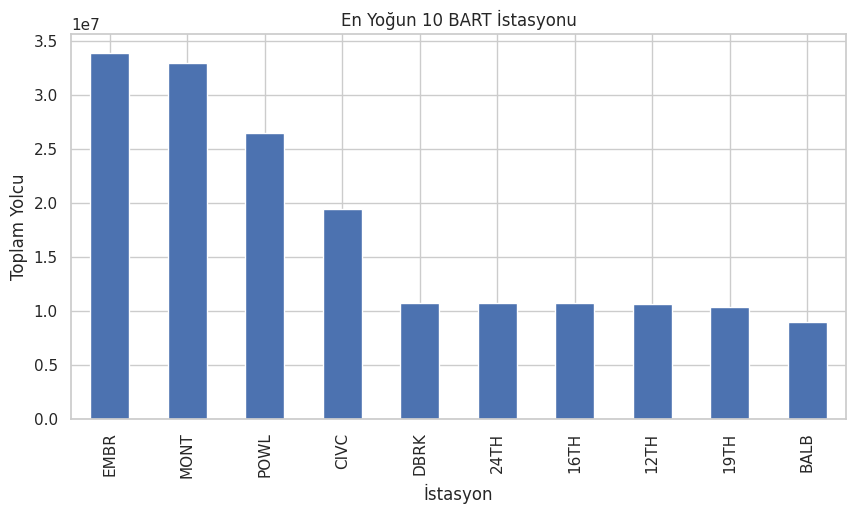

In [38]:
busy = pd.concat([
    df.groupby("origin")["throughput"].sum(),
    df.groupby("destination")["throughput"].sum()
]).groupby(level=0).sum().sort_values(ascending=False).head(10)

busy.plot(kind="bar", figsize=(10,5), title="En Yoğun 10 BART İstasyonu")
plt.ylabel("Toplam Yolcu")
plt.xlabel("İstasyon")
plt.show()

#### _What is the least popular BART route?_

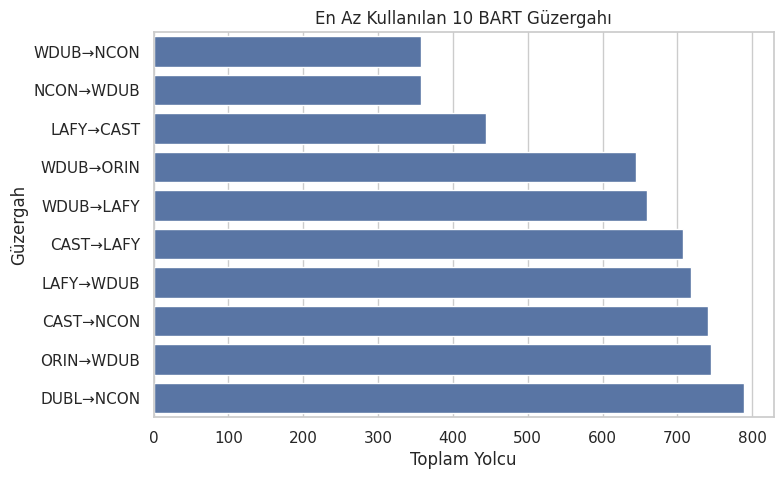

In [39]:
route = df.groupby(["origin","destination"])["throughput"].sum().sort_values().head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=route.values, y=[f"{i[0]}→{i[1]}" for i in route.index])
plt.title("En Az Kullanılan 10 BART Güzergahı")
plt.xlabel("Toplam Yolcu")
plt.ylabel("Güzergah")
plt.show()

#### _When is the best time to go to SF from Berkeley if you want to find a seat?_

In [40]:
berkeley = ["ASHB","DBRK","NBRK"]

In [41]:
sf = ["16TH","24TH","CIVC","POWL","MONT","EMBR"]

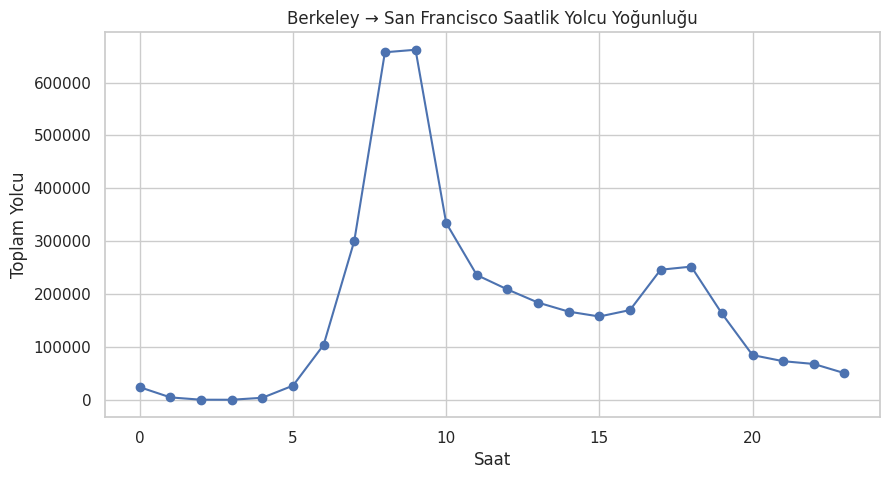

In [42]:
berk_sf = df[
    df.origin.isin(berkeley) &
    df.destination.isin(sf)
]

hourly = berk_sf.groupby("hour")["throughput"].sum()

hourly.plot(marker="o", figsize=(10,5),
            title="Berkeley → San Francisco Saatlik Yolcu Yoğunluğu")
plt.xlabel("Saat")
plt.ylabel("Toplam Yolcu")
plt.show()

#### _Which day of the week is the busiest?_

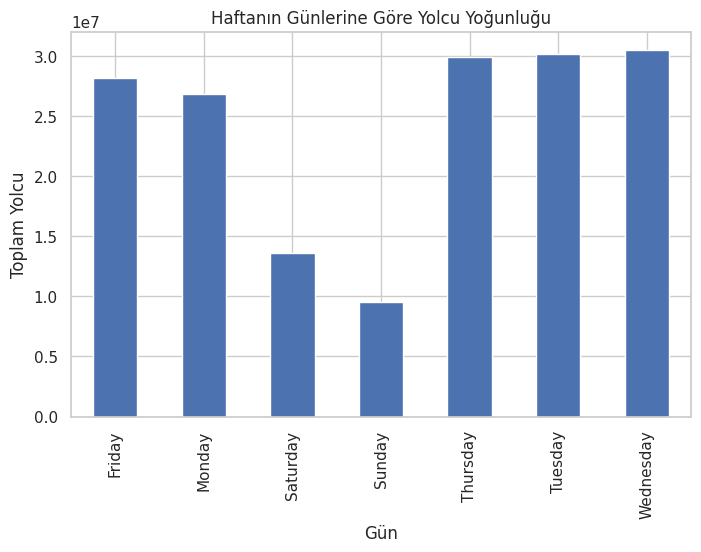

In [43]:
day_busy = df.groupby("day")["throughput"].sum()

day_busy.plot(kind="bar", figsize=(8,5),
              title="Haftanın Günlerine Göre Yolcu Yoğunluğu")
plt.ylabel("Toplam Yolcu")
plt.xlabel("Gün")
plt.show()

#### _How many people take the BART late at night?_

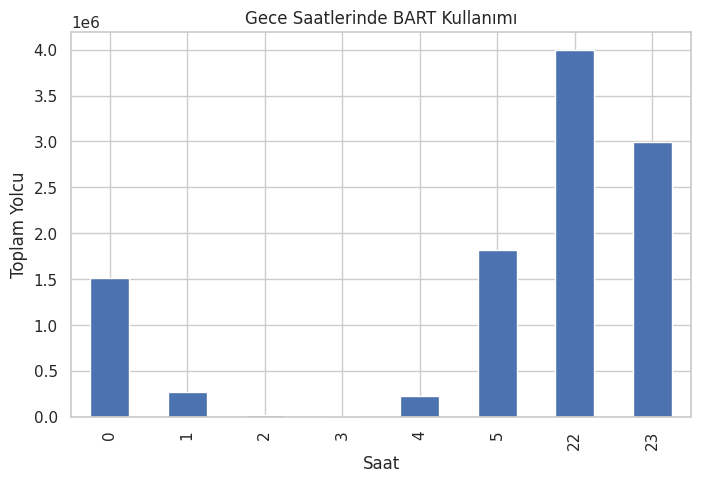

In [44]:
night = df[(df.hour >= 22) | (df.hour <= 5)]

night_usage = night.groupby("hour")["throughput"].sum()

night_usage.plot(kind="bar", figsize=(8,5),
                 title="Gece Saatlerinde BART Kullanımı")
plt.xlabel("Saat")
plt.ylabel("Toplam Yolcu")
plt.show()

### _Data Science Questions_

#### _Question A: Compute the straight line distance between every station_

In [45]:
df["distance_km"] = (
    6371 * np.arccos(
        np.sin(np.radians(df.origin_lat)) * np.sin(np.radians(df.dest_lat)) +
        np.cos(np.radians(df.origin_lat)) * np.cos(np.radians(df.dest_lat)) *
        np.cos(np.radians(df.dest_lon - df.origin_lon))
    )
)

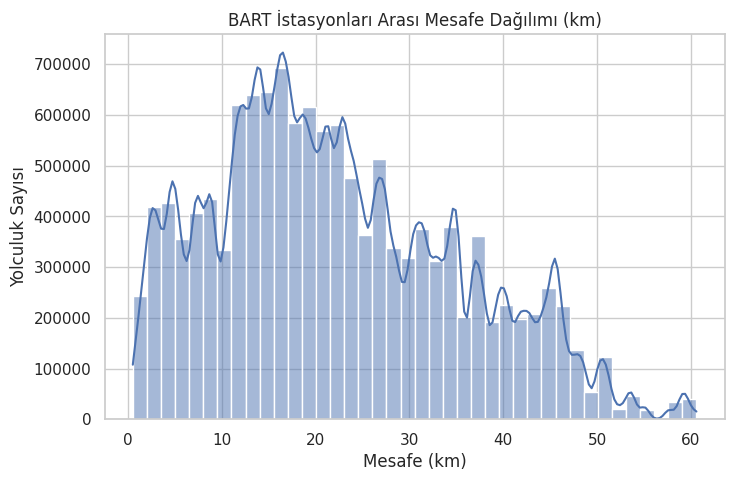

In [46]:
plt.figure(figsize=(8,5))
sns.histplot(df["distance_km"], bins=40, kde=True)
plt.title("BART İstasyonları Arası Mesafe Dağılımı (km)")
plt.xlabel("Mesafe (km)")
plt.ylabel("Yolculuk Sayısı")
plt.show()

#### _Question B: Build a model that can predict the number of people commuting to work by Bart between any 2 stations:_

##### **_Modeli İyileştirebilecek Ek Veriler_**

_Bu çalışma yalnızca istasyonlar arasındaki tarihsel BART yolcu verilerini kullanmaktadır.
Ancak, ek dış veri kaynakları mevcut olsaydı modelin tahmin performansı önemli ölçüde artırılabilirdi._

_Gelecek çalışmalarda aşağıdaki veriler modele dahil edilebilir:_

- **_Resmî tatiller ve özel günler:_** _Tatillerde yolcu kullanım desenleri, normal hafta içi günlerinden büyük ölçüde farklılık gösterir._
- **_Hava koşulları:_** _Yağmur, aşırı sıcaklar veya fırtınalar toplu taşıma kullanımını artırabilir._
- **_Büyük etkinlikler:_** _Konserler, spor müsabakaları ve festivaller yolcu sayısında geçici artışlara neden olabilir._
- **_İstasyon çevresindeki istihdam yoğunluğu:_** _İş merkezlerine yakın istasyonlar genellikle daha yüksek işe gidiş-geliş trafiğine sahiptir._
- **_Hizmet aksaklıkları ve bakım programları:_** _Gecikmeler veya hat kapanışları yolcu hacmini doğrudan etkiler._
- **_Sefer sıklığı ve kapasite:_** _Tren sayısı ve mevcut koltuk kapasitesi talebi etkileyebilir._

_Bu değişkenlerin dahil edilmesi, modelin yolcu davranışını etkileyen gerçek dünya faktörlerini daha iyi yakalamasını sağlayacaktır._

##### **_Şehir veya BART Yetkililerinin Bu Analizi Nasıl Kullanabileceği_**

_Bu projede geliştirilen içgörüler ve modeller, şehir planlamacıları ve BART yetkilileri için
birçok açıdan değerli olabilir:_

- **_Tren seferlerinin optimize edilmesi:_** _Yoğun talep saatlerinde sefer sıklığının artırılması._
- **_Yolcu konforunun iyileştirilmesi:_** _Aşırı yoğun hatlara daha fazla vagon veya tren eklenmesi._
- **_Kapasite planlaması:_** _Gelecekteki talebin öngörülmesi ve altyapı yatırımlarının planlanması._
- **_Operasyonel verimlilik:_** _Düşük talep saatlerinde gereksiz seferlerin azaltılması._
- **_Sürdürülebilirlik hedefleri:_** _Trafik yoğunluğunu ve karbon salınımını azaltmak için toplu taşıma kullanımının teşvik edilmesi._
- **_Veriye dayalı karar alma:_** _Ulaşım sisteminin proaktif şekilde yönetilmesi için tahminsel analitiklerin kullanılması._

_Genel olarak bu analiz, daha akıllı ve daha verimli kentsel ulaşım planlamasını
desteklemede veriye dayalı yaklaşımların nasıl kullanılabileceğini göstermektedir._

### _Modelling_

#### _X , Y_

In [47]:
df = df.sample(n=30_000, random_state=42)

In [48]:
x = df[[
    "origin",
    "destination",
    "hour",
    "weekday",
    "distance_km"
]]

y = df["throughput"]

In [49]:
x = pd.get_dummies(x, drop_first=True)
# Kategorik değişkenleri (örneğin 'zipcode') one-hot encoding yöntemiyle sayısal değerlere dönüştürür.
# drop_first=True, çoklu doğrusal bağımlılığı (dummy trap) önlemek için ilk kategoriyi kaldırır.

In [50]:
x.head()
# Dönüştürülmüş veri setinin ilk 5 satırını gösterir.
# Encoding işleminin doğru uygulanıp uygulanmadığını kontrol etmek için kullanılır.

,hour,weekday,distance_km,origin_16TH,origin_19TH,origin_24TH,origin_ASHB,origin_BALB,origin_BAYF,origin_CAST,origin_CIVC,origin_COLM,origin_COLS,origin_CONC,origin_DALY,origin_DBRK,origin_DELN,origin_DUBL,origin_EMBR,origin_FRMT,origin_FTVL,origin_GLEN,origin_HAYW,origin_LAFY,origin_LAKE,origin_MCAR,origin_MLBR,...,destination_FTVL,destination_GLEN,destination_HAYW,destination_LAFY,destination_LAKE,destination_MCAR,destination_MLBR,destination_MONT,destination_NBRK,destination_NCON,destination_OAKL,destination_ORIN,destination_PHIL,destination_PITT,destination_PLZA,destination_POWL,destination_RICH,destination_ROCK,destination_SANL,destination_SBRN,destination_SFIA,destination_SHAY,destination_SSAN,destination_UCTY,destination_WCRK,destination_WDUB,destination_WOAK
12512283,18,5,14.943048,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
5013548,7,2,41.624719,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
8419886,10,3,13.491787,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
10269933,21,4,13.984611,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3315070,20,1,35.290810,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False


In [52]:
 # Veriyi eğitim (%80) ve test (%20) olarak ayırma
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

#### _Algo Test_

In [55]:
#!pip install xgboost

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")  # Uyarı mesajlarını gizler.
pd.set_option("display.max_columns",100)  # Tüm sütunların görünmesini sağlar.

# Gerekli model kütüphaneleri
from sklearn.linear_model import LinearRegression, SGDRegressor, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor, RadiusNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree, ExtraTreeRegressor
from xgboost import XGBRegressor  # XGBoost modeli
from sklearn.svm import SVR  # Destek vektör regresyonu
from sklearn.neural_network import MLPRegressor  # Yapay sinir ağı tabanlı regresyon

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from sklearn.preprocessing import StandardScaler, MinMaxScaler  # Veri ölçekleme araçları

# Tüm modelleri test eden fonksiyon
def algo_test(x, y):
    # Modelleri tanımlama
    L = LinearRegression()
    R = Ridge()
    Lass = Lasso()
    E = ElasticNet()
    sgd = SGDRegressor()
    ETR = ExtraTreeRegressor()
    GBR = GradientBoostingRegressor()
    kn = KNeighborsRegressor()
    rkn = RadiusNeighborsRegressor(radius=1.0)
    ada = AdaBoostRegressor()
    dt = DecisionTreeRegressor()
    xgb = XGBRegressor()
    svr = SVR()
    mlp_regressor = MLPRegressor()

    # Model listesi ve isimleri
    algos = [L, R, Lass, E, sgd, ETR, GBR, ada, kn, dt, xgb, svr, mlp_regressor]
    algo_names = [
        'Linear', 'Ridge', 'Lasso', 'ElasticNet', 'SGD', 'Extra Tree',
        'Gradient Boosting', 'KNeighborsRegressor', 'AdaBoost',
        'Decision Tree', 'XGBRegressor', 'SVR', 'MLP Regressor'
    ]

    # Veriyi 0-1 aralığına ölçekleme (Min-Max Normalization)
    x = MinMaxScaler().fit_transform(x)

    # Veriyi eğitim (%80) ve test (%20) olarak ayırma
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

    # Performans metriklerini depolamak için listeler
    r_squared = []
    rmse = []
    mae = []

    # Sonuç tablosu oluşturma
    result = pd.DataFrame(columns=['R_Squared', 'RMSE', 'MAE'], index=algo_names)

    # Tüm modelleri sırayla eğitip test etme
    for algo in algos:
        p = algo.fit(x_train, y_train).predict(x_test)
        r_squared.append(r2_score(y_test, p))  # Modelin açıklama gücü
        rmse.append(mean_squared_error(y_test, p) ** 0.5)  # Hata (Root Mean Squared Error)
        mae.append(mean_absolute_error(y_test, p))  # Ortalama mutlak hata

    # Sonuç tablosunu doldurma
    result.R_Squared = r_squared
    result.RMSE = rmse
    result.MAE = mae

    # R² değerine göre en başarılı modelden en zayıfa doğru sıralama
    rtable = result.sort_values('R_Squared', ascending=False)
    return rtable

In [57]:
algo_test(x,y)

,R_Squared,RMSE,MAE
XGBRegressor,0.690679,21.246490,6.868401
Decision Tree,0.601482,24.116070,6.906028
Extra Tree,0.547116,25.708455,7.745500
Gradient Boosting,0.416675,29.176821,10.155161
MLP Regressor,0.385954,29.935265,11.304715
AdaBoost,0.323035,31.431545,10.668567
Linear,0.146986,35.282605,13.114557
Ridge,0.146955,35.283250,13.104595
SGD,0.146538,35.291887,13.100958
SVR,0.079061,36.660482,9.837488


### *Neural Network Modeli*

#### _İmport_

In [60]:
#pip install tensorflow

In [61]:
from tensorflow.keras.models import Sequential
# Sequential: katmanları sırayla ekleyerek model kurmamızı sağlar

from tensorflow.keras.layers import Dense
# Dense: tam bağlantılı (fully connected) yapay sinir ağı katmanı

from sklearn.preprocessing import StandardScaler
# Verileri ölçeklemek (standartlaştırmak) için kullanılan sınıf

In [62]:
from tensorflow.keras.callbacks import EarlyStopping
# EarlyStopping: Eğitim sırasında belirli bir metrik iyileşmeyi durdurduğunda
# modeli otomatik olarak durduran callback yapısıdır.
# Overfitting'i engellemek ve gereksiz yere uzun eğitim süresini azaltmak için kullanılır.

# Aynı dosya içinde önceden import ettiğim kütüphaneleri tekrar import etmeme gerek yok

#### *Verilerin Standardize Edilmesi (StandardScaler)*

In [63]:
scaler = StandardScaler()
# StandardScaler nesnesi oluşturulur (ortalama=0, std=1 olacak şekilde ölçeklendirme yapar)

x = scaler.fit_transform(x)
# X verisi önce "fit" edilip (ortalama ve std hesaplanır)
# ardından "transform" edilip ölçeklendirilir
# Modelin daha hızlı ve stabil öğrenmesini sağlar

#### *Neural Network Modeli - Early Stopping*

In [64]:
model = Sequential()
# Boş bir yapay sinir ağı modeli oluşturulur

model.add(Dense(64, activation='relu'))
# İlk gizli katman: 64 nöron, ReLU aktivasyonu

model.add(Dense(128, activation='relu'))
# İkinci gizli katman: 128 nöron, öğrenme kapasitesini artırır

model.add(Dense(256, activation='relu'))
# Üçüncü gizli katman: 256 nöron, modelin en geniş katmanı

model.add(Dense(128, activation='relu'))
# Dördüncü gizli katman: 128 nöron, daralmaya başlıyor

model.add(Dense(64, activation='relu'))
# Beşinci gizli katman: 64 nöron

model.add(Dense(32, activation='relu'))
# Altıncı gizli katman: 32 nöron

model.add(Dense(1))
# Çıkış katmanı: 1 nöron (regresyon problemi olduğu için aktivasyon kullanılmaz)

model.compile(loss='mean_squared_error', optimizer='adam')
# loss = MSE → regresyon için uygun hata fonksiyonu
# optimizer = adam → ağırlıkları güncellemek için kullanılan optimizasyon algoritması

In [65]:
early_stop = EarlyStopping(
    monitor='val_loss',  # İzlenen metrik: doğrulama kaybı (validation loss)
    patience=10          # 10 epoch boyunca iyileşme olmazsa eğitim durur
)
# EarlyStopping overfitting'i önler ve gereksiz uzun eğitim süresini kısaltır

In [66]:
history = model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),  # Test verisi doğrulama için kullanılıyor
    epochs=130,                        # Maksimum eğitim sayısı
    batch_size=32,                     # Her adımda 32 örnek işlenir
    callbacks=[early_stop],            # EarlyStopping aktif: val_loss iyileşmezse durdurur
    verbose=1                          # Eğitim bilgilerini ekrana yazdırır
)
# EarlyStopping sayesinde model gereksiz yere uzun süre eğitilmez
# En iyi validation loss değerinin olduğu epoch’ta eğitim sonlanır

Epoch 1/130
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1036.5729 - val_loss: 1219.1625
Epoch 2/130
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 933.2373 - val_loss: 1049.6775
Epoch 3/130
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 769.7613 - val_loss: 1105.5820
Epoch 4/130
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 616.3314 - val_loss: 811.9115
Epoch 5/130
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 648.3759 - val_loss: 748.3020
Epoch 6/130
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 794.5125 - val_loss: 863.4290
Epoch 7/130
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 548.9176 - val_loss: 661.1932
Epoch 8/130
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 495.0134 - val_loss: 710.5187
Epoch 9/130
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 570.4214 - val_loss: 1126.1018
Epoch 10/130
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 560.8254 - val_loss: 603.3112
Epoch 11/130
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 507.7188 - val_loss: 6

In [67]:
tahmin = model.predict(x_test)
# Eğitilen modelin test verisi üzerindeki tahminlerini üretir
# Regresyon problemi olduğu için çıktı, aracın fiyat tahminidir (sürekli sayısal değer)

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 788us/step


In [68]:
r2_score(tahmin, y_test)
# Yanlış kullanım! r2_score fonksiyonu önce gerçek değerleri (y_true),
# sonra tahmin değerlerini (y_pred) ister.
# Bu nedenle doğru kullanım aşağıdaki gibi olmalıdır:
# r2_score(y_test, tahmin)

0.437267541885376

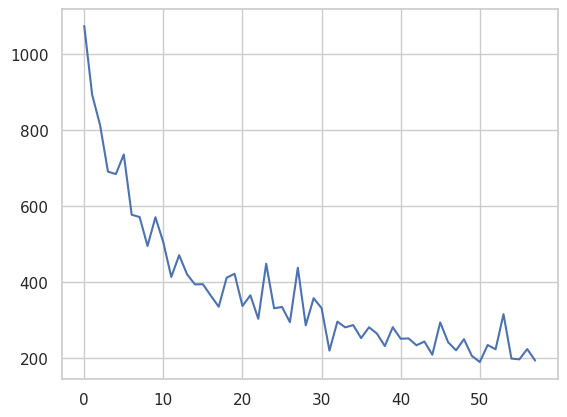

In [69]:
plt.plot(history.history['loss'])
# Eğitim sürecindeki 'loss' (MSE) değerlerinin epoch'lara göre değişimini çizer
# Eğri aşağı doğru gidiyorsa modelin öğrenmeye devam ettiği anlamına gelir

### *Proje Sonuçları ve Değerlendirme*

Bu projede Bay Area Rapid Transit (BART) yolcu verileri kullanılarak,
istasyonlar arası yolcu yoğunluğu analiz edilmiş ve yolcu sayısı tahmini
için Makine Öğrenmesi (ML) ve Derin Öğrenme (Deep Learning) modelleri
karşılaştırılmıştır.

---

### Veri Hazırlığı ve Ön İşleme

- 2016 ve 2017 yıllarına ait yolcu verileri birleştirilmiştir.
- Tarih bilgisi saat, gün ve haftanın günü olacak şekilde ayrıştırılmıştır.
- İstasyon koordinatları (latitude–longitude) ana veri seti ile birleştirilmiştir.
- Modelleme için 30.000 satırlık temsil gücü yüksek bir örneklem kullanılmıştır.
- Hedef değişken: **throughput (yolcu sayısı)**

---

### Makine Öğrenmesi Sonuçları

Birden fazla regresyon algoritması test edilmiştir.
En başarılı modeller aşağıda özetlenmiştir:

| Model | R² |
|-----|-----|
| **XGBRegressor** | **0.69** |
| Decision Tree | 0.60 |
| Extra Tree | 0.55 |
| Gradient Boosting | 0.41 |
| Linear / Ridge / Lasso | ~0.14 |

**Yorum:**
- Ağaç tabanlı ve boosting modelleri doğrusal modellere kıyasla
  çok daha iyi performans göstermiştir.
- Bu durum, yolcu sayısı ile değişkenler arasındaki ilişkinin
  doğrusal olmadığını göstermektedir.
- XGBoost modeli, karmaşık örüntüleri yakalayabildiği için
  en yüksek açıklama gücüne (R² ≈ 0.69) ulaşmıştır.

---

### Derin Öğrenme Sonuçları

Tam bağlantılı (Dense) katmanlardan oluşan bir sinir ağı modeli eğitilmiştir.

- Kullanılan veri sayısı: 30.000
- Eğitim süresi: kısa (CPU ortamında)
- Elde edilen sonuç: R² = 0.437


**Yorum:**
- Derin öğrenme modeli, doğrusal modellere göre daha iyi sonuç vermiştir.
- Ancak XGBoost gibi güçlü ağaç tabanlı modellerin gerisinde kalmıştır.
- Bunun temel nedeni, verinin tabular (sayısal) yapıda olması ve
  derin öğrenmenin bu tür verilerde her zaman avantaj sağlamamasıdır.

---

### ML ve Deep Learning Karşılaştırması

| Yaklaşım | Avantaj | Sonuç |
|-------|--------|------|
| Makine Öğrenmesi | Daha hızlı, daha açıklanabilir | **Daha başarılı** |
| Deep Learning | Karmaşık yapıları öğrenebilir | Orta seviye performans |

Bu projede, **geleneksel makine öğrenmesi modellerinin**
derin öğrenmeye kıyasla daha uygun olduğu görülmüştür.

---

### Sonuç ve Genel Değerlendirme

- Yolcu sayısı; hava durumu, tatiller, özel etkinlikler ve operasyonel
  faktörler gibi veri setinde yer almayan değişkenlerden etkilenmektedir.
- Buna rağmen ağaç tabanlı modeller anlamlı tahminler üretebilmiştir.
- Proje kapsamında:
  - Veri analizi,
  - Özellik mühendisliği,
  - ML ve DL model karşılaştırması
  başarıyla gerçekleştirilmiştir.

Bu çalışma, BART yetkililerinin yoğun saatleri ve yoğun hatları
belirlemesi için karar destek sistemi olarak kullanılabilir.


